# Modelo Visual — AUs Temporais para Detecção de A/H
Pipeline: .npy AU features → vetorização temporal → XGBoost baseline + LSTM

In [54]:
# CÉLULA 1: Imports e configuração
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === AJUSTE ESSES PATHS ===
BASE_DIR = r'C:\Users\ddonz\OneDrive\Documentos\Aislan\data'
SPLIT_DIR = os.path.join(BASE_DIR, 'split')
AU_DIR = os.path.join(BASE_DIR, 'au_features')

AU_NAMES = [
    'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10',
    'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24',
    'AU25', 'AU26', 'AU28', 'AU43'
]

# IDs excluídos (sem consentimento / problemas)
EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"AU features dir: {AU_DIR}")
print(f"Splits dir: {SPLIT_DIR}")

Device: cuda
AU features dir: C:\Users\ddonz\OneDrive\Documentos\Aislan\data\au_features
Splits dir: C:\Users\ddonz\OneDrive\Documentos\Aislan\data\split


In [55]:
# CÉLULA 2: Carregar splits e mapear para arquivos .npy

def load_split_with_au(split_file, au_dir, excluded_ids):
    """Carrega split e encontra o .npy correspondente a cada vídeo."""
    data = []
    missing = 0
    excluded = 0
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]  # Videos/{pid}/Visite_1/{video_name}
            label = int(parts[1])
            
            # Extrair participant_id e video_name
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1]  # ex: 82553_Question_1_2024-08-22_12-...
            
            if pid in excluded_ids:
                excluded += 1
                continue
            
            # Buscar .npy correspondente
            npy_path = os.path.join(au_dir, pid, f"{video_name}.npy")
            if not os.path.exists(npy_path):
                # Tentar sem extensão .mp4 no nome
                npy_path2 = os.path.join(au_dir, pid, f"{video_name.replace('.mp4', '')}.npy")
                if os.path.exists(npy_path2):
                    npy_path = npy_path2
                else:
                    missing += 1
                    continue
            
            data.append({
                'pid': pid,
                'video_name': video_name,
                'npy_path': npy_path,
                'label': label
            })
    
    return data, missing, excluded

train_data, train_miss, train_excl = load_split_with_au(
    os.path.join(SPLIT_DIR, 'train.txt'), AU_DIR, EXCLUDED_IDS)
val_data, val_miss, val_excl = load_split_with_au(
    os.path.join(SPLIT_DIR, 'val.txt'), AU_DIR, EXCLUDED_IDS)
test_data, test_miss, test_excl = load_split_with_au(
    os.path.join(SPLIT_DIR, 'test.txt'), AU_DIR, EXCLUDED_IDS)

for name, data, miss, excl in [('Train', train_data, train_miss, train_excl),
                                 ('Val', val_data, val_miss, val_excl),
                                 ('Test', test_data, test_miss, test_excl)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos (excluídos: {excl}, missing .npy: {miss}) | "
          f"AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)")

Train: 598 vídeos (excluídos: 180, missing .npy: 0) | AH=297 (49.7%)
Val: 107 vídeos (excluídos: 17, missing .npy: 0) | AH=65 (60.7%)
Test: 427 vídeos (excluídos: 98, missing .npy: 0) | AH=256 (60.0%)


In [56]:
# DIAGNÓSTICO: checar NaN/inf nos .npy
nan_count = 0
inf_count = 0
nan_videos = []

for split_data in [train_data, val_data, test_data]:
    for item in split_data:
        arr = np.load(item['npy_path'])
        if np.isnan(arr).any():
            nan_count += 1
            nan_videos.append(item['video_name'])
        if np.isinf(arr).any():
            inf_count += 1

print(f"Vídeos com NaN: {nan_count}")
print(f"Vídeos com inf: {inf_count}")
if nan_videos:
    print(f"Exemplos: {nan_videos[:5]}")

# Checar range dos valores
all_vals = []
for item in train_data[:50]:
    arr = np.load(item['npy_path'])
    all_vals.append(arr)
all_vals = np.vstack(all_vals)
print(f"\nRange: [{np.nanmin(all_vals):.4f}, {np.nanmax(all_vals):.4f}]")
print(f"NaN total: {np.isnan(all_vals).sum()} / {all_vals.size}")

Vídeos com NaN: 251
Vídeos com inf: 0
Exemplos: ['82750_Question_5_2024-11-28_01-13-30_Video.mp4', '82743_Question_7_2024-11-27_18-10-13_Video.mp4', '82585_Question_3_2024-10-02_16-09-36_Video.mp4', '82645_Question_6_2024-11-11_15-27-42_Video.mp4', '83046_Question_4_2025-05-08_13-53-06_Video.mp4']

Range: [0.0000, 1.0000]
NaN total: 1500 / 229740


In [57]:
# CÉLULA 3: Vetorização temporal — extrair features estatísticas de cada série AU

def compute_temporal_features(au_sequence):
    """
    Transforma série temporal (N_frames, 20) em vetor fixo de features.
    Para cada AU: mean, std, slope, range, iqr, zero_crossing_rate, max, skewness
    = 8 features × 20 AUs = 160 features
    """
    au_seq = au_sequence.astype(np.float64)
    n_frames, n_aus = au_seq.shape
    
    features = []
    
    for au_idx in range(n_aus):
        signal = au_seq[:, au_idx]
        
        # 1. Média
        feat_mean = np.mean(signal)
        
        # 2. Desvio padrão (variabilidade)
        feat_std = np.std(signal)
        
        # 3. Slope (tendência linear via regressão)
        if n_frames > 1:
            x = np.arange(n_frames)
            feat_slope = np.polyfit(x, signal, 1)[0]
        else:
            feat_slope = 0.0
        
        # 4. Range (max - min)
        feat_range = np.max(signal) - np.min(signal)
        
        # 5. IQR (interquartil range — robustez a outliers)
        q75, q25 = np.percentile(signal, [75, 25])
        feat_iqr = q75 - q25
        
        # 6. Zero-crossing rate (frequência de mudança de direção)
        if n_frames > 2:
            diff = np.diff(signal)
            zcr = np.sum(np.abs(np.diff(np.sign(diff))) > 0) / len(diff)
        else:
            zcr = 0.0
        
        # 7. Máximo
        feat_max = np.max(signal)
        
        # 8. Skewness (assimetria da distribuição)
        if feat_std > 1e-8:
            feat_skew = float(np.mean(((signal - feat_mean) / feat_std) ** 3))
        else:
            feat_skew = 0.0
        
        features.extend([feat_mean, feat_std, feat_slope, feat_range,
                         feat_iqr, zcr, feat_max, feat_skew])
    
    return np.array(features)


def vectorize_split(data_list):
    """Vetoriza todos os vídeos de um split."""
    X, y = [], []
    for item in data_list:
        au_seq = np.load(item['npy_path'])
        if len(au_seq) == 0:
            continue
        feats = compute_temporal_features(au_seq)
        X.append(feats)
        y.append(item['label'])
    return np.array(X), np.array(y)


X_train, y_train = vectorize_split(train_data)
X_val, y_val = vectorize_split(val_data)
X_test, y_test = vectorize_split(test_data)

print(f"Feature vector: {X_train.shape[1]} dimensões (8 features × 20 AUs)")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train AH: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.1f}%)")

Feature vector: 160 dimensões (8 features × 20 AUs)
Train: (598, 160) | Val: (107, 160) | Test: (427, 160)
Train AH: 297/598 (49.7%)


In [58]:
# CÉLULA 4: Baseline XGBoost com busca de hiperparâmetros
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

# Normalizar features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Grid search simples
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [y_train.sum() / (len(y_train) - y_train.sum()), 1.0],
}

best_f1 = 0
best_params = None
best_model = None

print(f"Testando {len(list(ParameterGrid(param_grid)))} combinações...")

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_sc, y_train)
    
    y_pred = model.predict(X_val_sc)
    f1 = f1_score(y_val, y_pred, average='macro')
    
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_model = model

print(f"\nMelhor Val Macro F1: {best_f1:.4f}")
print(f"Params: {best_params}")

# Avaliar no test
y_test_pred = best_model.predict(X_test_sc)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Test Macro F1: {test_f1:.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['No AH', 'AH'])}")

Testando 54 combinações...

Melhor Val Macro F1: 0.6194
Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1.0}
Test Macro F1: 0.5642

              precision    recall  f1-score   support

       No AH       0.47      0.58      0.52       171
          AH       0.67      0.56      0.61       256

    accuracy                           0.57       427
   macro avg       0.57      0.57      0.56       427
weighted avg       0.59      0.57      0.57       427



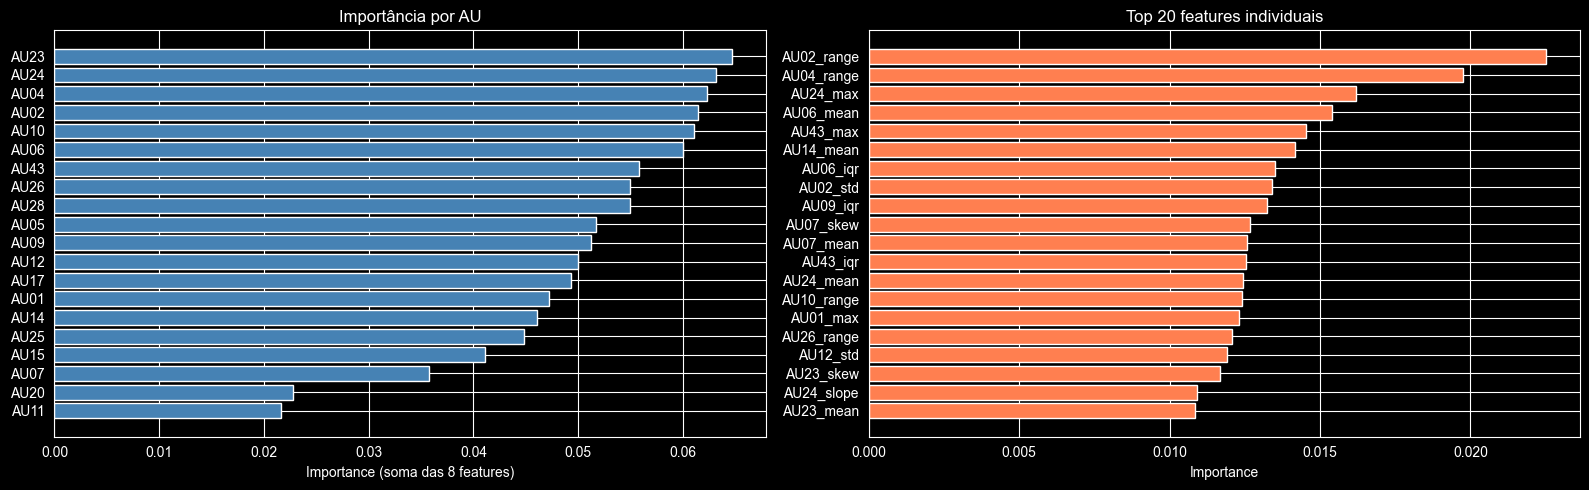

In [59]:
# CÉLULA 5: Feature importance — quais AUs/features mais discriminam
importances = best_model.feature_importances_

# Agrupar por AU (8 features por AU)
feat_names = ['mean', 'std', 'slope', 'range', 'iqr', 'zcr', 'max', 'skew']
au_importances = {}
for i, au_name in enumerate(AU_NAMES):
    start = i * 8
    au_importances[au_name] = importances[start:start+8].sum()

# Plot por AU
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AU-level importance
sorted_aus = sorted(au_importances.items(), key=lambda x: -x[1])
aus, vals = zip(*sorted_aus)
axes[0].barh(range(len(aus)), vals, color='steelblue')
axes[0].set_yticks(range(len(aus)))
axes[0].set_yticklabels(aus)
axes[0].set_xlabel('Importance (soma das 8 features)')
axes[0].set_title('Importância por AU')
axes[0].invert_yaxis()

# Top 20 features individuais
full_names = [f"{AU_NAMES[i//8]}_{feat_names[i%8]}" for i in range(len(importances))]
top_idx = np.argsort(importances)[-20:][::-1]
axes[1].barh(range(20), importances[top_idx], color='coral')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([full_names[i] for i in top_idx])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 20 features individuais')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [60]:
# CÉLULA 6: Dataset e DataLoader para LSTM

class AUSequenceDataset(Dataset):
    """Dataset com limpeza de NaN e normalização por sequência."""
    def __init__(self, data_list, max_len=256, stats=None):
        self.items = []
        for item in data_list:
            au_seq = np.load(item['npy_path']).astype(np.float64)
            if len(au_seq) == 0:
                continue
            # Substituir NaN e inf por 0
            au_seq = np.nan_to_num(au_seq, nan=0.0, posinf=1.0, neginf=0.0)
            # Clipar valores extremos
            au_seq = np.clip(au_seq, 0.0, 5.0)
            self.items.append((au_seq, item['label']))
        self.max_len = max_len

        # Calcular stats de normalização no treino
        if stats is None:
            all_frames = np.vstack([item[0] for item in self.items])
            self.mean = np.nanmean(all_frames, axis=0)
            self.std = np.nanstd(all_frames, axis=0)
            self.std[self.std < 1e-8] = 1.0  # evitar divisão por zero
        else:
            self.mean, self.std = stats

    def get_stats(self):
        return (self.mean, self.std)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        au_seq, label = self.items[idx]
        seq_len = len(au_seq)

        # Normalizar
        au_seq = (au_seq - self.mean) / self.std

        # Truncar ou paddar
        if seq_len > self.max_len:
            indices = np.linspace(0, seq_len - 1, self.max_len, dtype=int)
            au_seq = au_seq[indices]
            mask = np.ones(self.max_len)
        else:
            pad_len = self.max_len - seq_len
            au_seq = np.vstack([au_seq, np.zeros((pad_len, 20))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])

        return (
            torch.FloatTensor(au_seq),
            torch.FloatTensor(mask),
            torch.FloatTensor([label])
        )


MAX_LEN = 256
BATCH_SIZE = 32

train_dataset = AUSequenceDataset(train_data, max_len=MAX_LEN)
train_stats = train_dataset.get_stats()  # usar mesma normalização pra val/test
val_dataset = AUSequenceDataset(val_data, max_len=MAX_LEN, stats=train_stats)
test_dataset = AUSequenceDataset(test_data, max_len=MAX_LEN, stats=train_stats)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Verificar que não tem mais NaN
x, m, y = next(iter(train_loader))
print(f"NaN no batch: {torch.isnan(x).any().item()}")
print(f"Range: [{x.min():.3f}, {x.max():.3f}]")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

NaN no batch: False
Range: [-4.779, 6.923]
Train: 598 | Val: 107 | Test: 427


In [61]:
# CÉLULA 7: Modelo LSTM

class AULSTM(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x, mask):
        # x: (B, T, 20), mask: (B, T)
        lstm_out, _ = self.lstm(x)  # (B, T, hidden*2)
        
        # Attention com mask
        attn_weights = self.attention(lstm_out).squeeze(-1)  # (B, T)
        attn_weights = attn_weights.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)  # (B, T)
        
        # Weighted sum
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)  # (B, hidden*2)
        
        logits = self.classifier(context)  # (B, 1)
        return logits


model = AULSTM(input_dim=20, hidden_dim=64, n_layers=2, dropout=0.3).to(device)
print(f"Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Parâmetros: 160,002
AULSTM(
  (lstm): LSTM(20, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [62]:
# CÉLULA 8: Treinar LSTM

# Class weight para lidar com desbalanceamento
n_pos = sum(d['label'] for d in train_data)
n_neg = len(train_data) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

N_EPOCHS = 100
best_val_f1 = 0
patience = 20
patience_counter = 0
history = {'train_loss': [], 'val_f1': []}

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0
    for x, mask, y in train_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x, mask)
        loss = criterion(logits, y)

        # Checar NaN no loss
        if torch.isnan(loss):
            print(f"NaN loss detectado na epoch {epoch+1}, pulando batch")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / max(len(train_loader), 1)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, mask, y in val_loader:
            x, mask = x.to(device), mask.to(device)
            logits = model(x, mask)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y.numpy().flatten())
    
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    history['train_loss'].append(avg_loss)
    history['val_f1'].append(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(BASE_DIR, 'best_visual_lstm.pt'))
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
              f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping na epoch {epoch+1}")
        break

print(f"\nMelhor Val Macro F1: {best_val_f1:.4f}")

Epoch   1 | Loss: 0.6970 | Val F1: 0.5133 | Best: 0.5133 *
Epoch   2 | Loss: 0.6942 | Val F1: 0.5334 | Best: 0.5334 *
Epoch   4 | Loss: 0.6875 | Val F1: 0.5482 | Best: 0.5482 *
Epoch   5 | Loss: 0.6772 | Val F1: 0.4810 | Best: 0.5482 
Epoch   6 | Loss: 0.6723 | Val F1: 0.5493 | Best: 0.5493 *
Epoch   8 | Loss: 0.6700 | Val F1: 0.5768 | Best: 0.5768 *
Epoch   9 | Loss: 0.6600 | Val F1: 0.5885 | Best: 0.5885 *
Epoch  10 | Loss: 0.6435 | Val F1: 0.5848 | Best: 0.5885 
Epoch  15 | Loss: 0.6049 | Val F1: 0.5436 | Best: 0.5885 
Epoch  20 | Loss: 0.5354 | Val F1: 0.4827 | Best: 0.5885 
Epoch  25 | Loss: 0.4837 | Val F1: 0.4789 | Best: 0.5885 

Early stopping na epoch 29

Melhor Val Macro F1: 0.5885


LSTM Test Macro F1: 0.5187

              precision    recall  f1-score   support

       No AH       0.42      0.44      0.43       171
          AH       0.62      0.59      0.60       256

    accuracy                           0.53       427
   macro avg       0.52      0.52      0.52       427
weighted avg       0.54      0.53      0.54       427



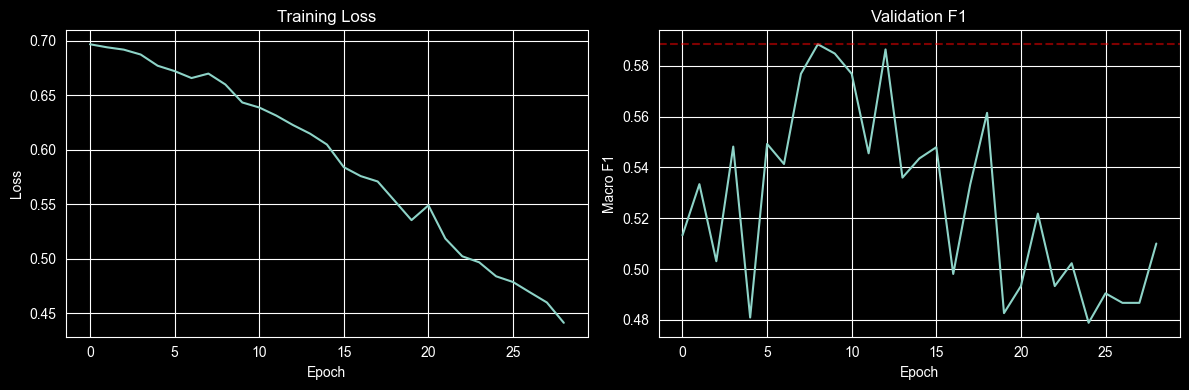

In [63]:
# CÉLULA 9: Avaliar LSTM no test set

# Carregar melhor modelo
model.load_state_dict(torch.load(os.path.join(BASE_DIR, 'best_visual_lstm.pt')))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask = x.to(device), mask.to(device)
        logits = model(x, mask)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y.numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())

test_f1_lstm = f1_score(all_labels, all_preds, average='macro')
print(f"LSTM Test Macro F1: {test_f1_lstm:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=['No AH', 'AH'])}")

# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[1].plot(history['val_f1'])
axes[1].axhline(best_val_f1, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].set_title('Validation F1')
plt.tight_layout()
plt.show()

In [64]:
# CÉLULA 10: Comparativo final
print("=" * 50)
print("RESULTADOS — Modalidade Visual (AUs)")
print("=" * 50)
print(f"Challenge baseline:      0.2827")
print(f"XGBoost (temporal):      {test_f1:.4f}")
print(f"LSTM + Attention:        {test_f1_lstm:.4f}")
print(f"Texto (BERT) referência: 0.5904")
print("=" * 50)

RESULTADOS — Modalidade Visual (AUs)
Challenge baseline:      0.2827
XGBoost (temporal):      0.5642
LSTM + Attention:        0.5187
Texto (BERT) referência: 0.5904


In [49]:
# CÉLULA 11: Sliding Window Dataset — janela deslizante como input do LSTM

class AUWindowDataset(Dataset):
    """Transforma série de AUs em sequência de janelas com stats temporais."""
    def __init__(self, data_list, window_size=16, window_step=8,
                 max_windows=64, stats=None):
        self.items = []
        self.window_size = window_size
        self.window_step = window_step
        self.max_windows = max_windows
        self.n_aus = 20
        self.feat_dim = self.n_aus * 4  # 4 stats × 20 AUs = 80

        all_windows = []
        for item in data_list:
            au_seq = np.load(item['npy_path']).astype(np.float64)
            au_seq = np.nan_to_num(au_seq, nan=0.0, posinf=1.0, neginf=0.0)
            au_seq = np.clip(au_seq, 0.0, 5.0)

            if len(au_seq) < window_size:
                continue

            # Calcular janelas
            windows = self._compute_windows(au_seq)
            all_windows.append(windows)
            self.items.append((windows, item['label']))

        # Normalização
        if stats is None:
            all_w = np.vstack(all_windows)
            self.mean = np.mean(all_w, axis=0)
            self.std = np.std(all_w, axis=0)
            self.std[self.std < 1e-8] = 1.0
        else:
            self.mean, self.std = stats

    def _compute_windows(self, au_seq):
        """Calcula 4 stats por AU em cada janela deslizante."""
        windows = []
        for start in range(0, len(au_seq) - self.window_size + 1, self.window_step):
            window = au_seq[start:start + self.window_size]
            feats = []
            for au_idx in range(self.n_aus):
                signal = window[:, au_idx]
                f_mean = np.mean(signal)
                f_std = np.std(signal)
                f_slope = np.polyfit(np.arange(self.window_size), signal, 1)[0]
                f_range = np.max(signal) - np.min(signal)
                feats.extend([f_mean, f_std, f_slope, f_range])
            windows.append(feats)
        return np.array(windows)  # (W, 80)

    def get_stats(self):
        return (self.mean, self.std)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        windows, label = self.items[idx]
        n_windows = len(windows)

        # Normalizar
        windows = (windows - self.mean) / self.std

        # Pad ou truncar
        if n_windows > self.max_windows:
            indices = np.linspace(0, n_windows - 1, self.max_windows, dtype=int)
            windows = windows[indices]
            mask = np.ones(self.max_windows)
        else:
            pad_len = self.max_windows - n_windows
            windows = np.vstack([windows, np.zeros((pad_len, self.feat_dim))])
            mask = np.concatenate([np.ones(n_windows), np.zeros(pad_len)])

        return (
            torch.FloatTensor(windows),   # (max_windows, 80)
            torch.FloatTensor(mask),       # (max_windows,)
            torch.FloatTensor([label])     # (1,)
        )


WINDOW_SIZE = 16   # ~1.6s a 10fps
WINDOW_STEP = 8    # 50% overlap
MAX_WINDOWS = 128   # cobre ~51s de vídeo

train_win_ds = AUWindowDataset(train_data, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS)
win_stats = train_win_ds.get_stats()
val_win_ds = AUWindowDataset(val_data, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS, stats=win_stats)
test_win_ds = AUWindowDataset(test_data, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS, stats=win_stats)

train_win_ld = DataLoader(train_win_ds, batch_size=32, shuffle=True)
val_win_ld = DataLoader(val_win_ds, batch_size=32)
test_win_ld = DataLoader(test_win_ds, batch_size=32)

x, m, y = next(iter(train_win_ld))
print(f"Batch shapes: x={x.shape}, mask={m.shape}, y={y.shape}")
print(f"Input dim: {train_win_ds.feat_dim} (4 stats × 20 AUs)")
print(f"Window: {WINDOW_SIZE} frames ({WINDOW_SIZE/10:.1f}s), step: {WINDOW_STEP}")
print(f"Train: {len(train_win_ds)} | Val: {len(val_win_ds)} | Test: {len(test_win_ds)}")
print(f"NaN: {torch.isnan(x).any().item()}")

Batch shapes: x=torch.Size([32, 128, 80]), mask=torch.Size([32, 128]), y=torch.Size([32, 1])
Input dim: 80 (4 stats × 20 AUs)
Window: 16 frames (1.6s), step: 8
Train: 598 | Val: 107 | Test: 427
NaN: False


In [50]:
# CÉLULA 12: Modelo LSTM com input de janelas (80 dims)

class AUWindowLSTM(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, mask):
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out).squeeze(-1)
        attn_weights = attn_weights.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)


win_model = AUWindowLSTM(input_dim=80, hidden_dim=64, n_layers=2, dropout=0.3).to(device)
print(f"Parâmetros: {sum(p.numel() for p in win_model.parameters()):,}")
print(win_model)

Parâmetros: 190,722
AUWindowLSTM(
  (lstm): LSTM(80, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [51]:
# CÉLULA 13: Treinar LSTM com janelas

n_pos = sum(d['label'] for d in train_data)
n_neg = len(train_data) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(win_model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

N_EPOCHS = 50
best_val_f1_win = 0
patience = 30
patience_counter = 0
history_win = {'train_loss': [], 'val_f1': []}

for epoch in range(N_EPOCHS):
    win_model.train()
    total_loss = 0
    for x, mask, y in train_win_ld:
        x, mask, y = x.to(device), mask.to(device), y.to(device)

        optimizer.zero_grad()
        logits = win_model(x, mask)
        loss = criterion(logits, y)

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(win_model.parameters(), 0.5)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / max(len(train_win_ld), 1)

    win_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, mask, y in val_win_ld:
            x, mask = x.to(device), mask.to(device)
            logits = win_model(x, mask)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y.numpy().flatten())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    history_win['train_loss'].append(avg_loss)
    history_win['val_f1'].append(val_f1)

    if val_f1 > best_val_f1_win:
        best_val_f1_win = val_f1
        patience_counter = 0
        torch.save(win_model.state_dict(), os.path.join(BASE_DIR, 'best_visual_window_lstm.pt'))
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
              f"| Best: {best_val_f1_win:.4f} {'*' if patience_counter == 0 else ''}")

    if patience_counter >= patience:
        print(f"\nEarly stopping na epoch {epoch+1}")
        break

print(f"\nMelhor Val Macro F1: {best_val_f1_win:.4f}")

Epoch   1 | Loss: 0.6980 | Val F1: 0.3779 | Best: 0.3779 *
Epoch   2 | Loss: 0.6925 | Val F1: 0.5848 | Best: 0.5848 *
Epoch   4 | Loss: 0.6711 | Val F1: 0.6030 | Best: 0.6030 *
Epoch   5 | Loss: 0.6581 | Val F1: 0.5973 | Best: 0.6030 
Epoch  10 | Loss: 0.4778 | Val F1: 0.5836 | Best: 0.6030 
Epoch  11 | Loss: 0.4583 | Val F1: 0.6223 | Best: 0.6223 *
Epoch  15 | Loss: 0.2935 | Val F1: 0.6044 | Best: 0.6223 
Epoch  16 | Loss: 0.2686 | Val F1: 0.6244 | Best: 0.6244 *
Epoch  17 | Loss: 0.2294 | Val F1: 0.6441 | Best: 0.6441 *
Epoch  20 | Loss: 0.1783 | Val F1: 0.6162 | Best: 0.6441 
Epoch  21 | Loss: 0.1568 | Val F1: 0.6473 | Best: 0.6473 *
Epoch  25 | Loss: 0.1034 | Val F1: 0.5946 | Best: 0.6473 
Epoch  30 | Loss: 0.0593 | Val F1: 0.6081 | Best: 0.6473 
Epoch  35 | Loss: 0.0291 | Val F1: 0.6081 | Best: 0.6473 
Epoch  40 | Loss: 0.0162 | Val F1: 0.6046 | Best: 0.6473 
Epoch  45 | Loss: 0.0155 | Val F1: 0.5885 | Best: 0.6473 
Epoch  50 | Loss: 0.0155 | Val F1: 0.5885 | Best: 0.6473 

Melhor

Window LSTM Test Macro F1: 0.5436

              precision    recall  f1-score   support

       No AH       0.45      0.56      0.50       171
          AH       0.65      0.54      0.59       256

    accuracy                           0.55       427
   macro avg       0.55      0.55      0.54       427
weighted avg       0.57      0.55      0.55       427



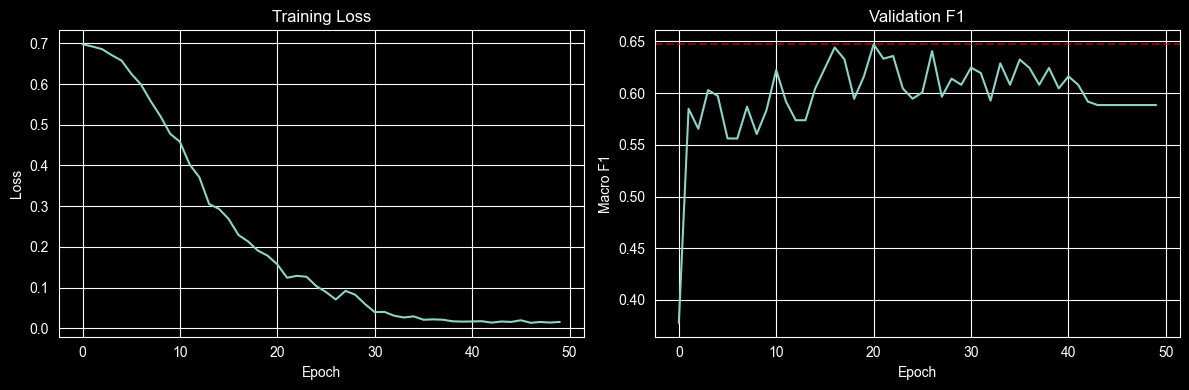

In [52]:
# CÉLULA 14: Avaliar no test

win_model.load_state_dict(torch.load(os.path.join(BASE_DIR, 'best_visual_window_lstm.pt')))
win_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, mask, y in test_win_ld:
        x, mask = x.to(device), mask.to(device)
        logits = win_model(x, mask)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y.numpy().flatten())

test_f1_win = f1_score(all_labels, all_preds, average='macro')
print(f"Window LSTM Test Macro F1: {test_f1_win:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=['No AH', 'AH'])}")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_win['train_loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[1].plot(history_win['val_f1'])
axes[1].axhline(best_val_f1_win, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].set_title('Validation F1')
plt.tight_layout()
plt.show()

In [53]:
# CÉLULA 15: Comparativo completo — 3 abordagens visuais com AUs

print("=" * 58)
print("RESULTADOS — Visual AUs: 3 abordagens")
print("=" * 58)
print(f"{'Modelo':<38} {'Val F1':>8} {'Test F1':>8}")
print("-" * 58)
print(f"{'Challenge baseline':<38} {'—':>8} {'0.2827':>8}")
print("-" * 58)
print(f"{'XGBoost (vetor 160d)':<38} {'0.6194':>8} {'0.5642':>8}")
print(f"{'LSTM raw (N, 20)':<38} {'0.5723':>8} {'0.5490':>8}")
print(f"{'LSTM window (W, 80)':<38} {best_val_f1_win:>8.4f} {test_f1_win:>8.4f}")
print("=" * 58)
print(f"\n  XGBoost: feature engineering → vetor fixo → tree")
print(f"  LSTM raw: série bruta → LSTM aprende dinâmica")
print(f"  LSTM window: janela com stats → LSTM aprende macro-dinâmica")

RESULTADOS — Visual AUs: 3 abordagens
Modelo                                   Val F1  Test F1
----------------------------------------------------------
Challenge baseline                            —   0.2827
----------------------------------------------------------
XGBoost (vetor 160d)                     0.6194   0.5642
LSTM raw (N, 20)                         0.5723   0.5490
LSTM window (W, 80)                      0.6473   0.5436

  XGBoost: feature engineering → vetor fixo → tree
  LSTM raw: série bruta → LSTM aprende dinâmica
  LSTM window: janela com stats → LSTM aprende macro-dinâmica
